**PART A : SHORT NOTES**

1. **Inferential Statistics** :- Using a sample to draw conclusions about a whole population.
2. **Hypothesis testing** :- A method to check a claim using data. Parts: H₀ (no effect), H₁ (effect exists), α (significance level), test statistic, p-value, decision.
3. **Confidence interval and critical value** :- A confidence interval is a range likely to contain the true value. The critical value is the cutoff that separates "reject" from "do not reject" (e.g. ±1.96 for z at 5%).
4. **p-value** :- Probability of getting a result this extreme if H₀ is true. Small p-value means evidence against H₀.
5. **Type I vs Type II error** :- ype I = rejecting a true H₀ (false alarm). Type II = failing to reject a false H₀ (missed effect).
6. **Tests** :- z-test* compares means for large samples. **t-test** compares means for small samples. **Chi-square** tests the link between two categories. **ANOVA** compares means of 3 or more groups.
7. **Covariance** :- Shows whether two variables move together (positive) or oppositely (negative). Depends on units.
8. **Correlation** :- Covariance scaled between −1 and +1. Shows the strength and direction of a linear relationship.

PART B : ANALYSIS

In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


df = pd.read_csv("health_dataset.csv")
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,PAT-100001,18-25,23,81,Female,West,Former Smoker,Never,16.5,119.2,False,False,238.7,106.0,2024-07-29
1,PAT-100002,60+,69,61,Female,East,Smoker,Weekly,16.7,139.5,False,True,193.9,85.9,2024-11-24
2,PAT-100003,60+,61,59,Female,West,Non-Smoker,Weekly,18.9,123.4,False,False,179.8,74.3,2024-11-19
3,PAT-100004,46-60,47,75,Female,East,Non-Smoker,Weekly,17.4,129.3,False,False,244.9,81.7,2024-08-16
4,PAT-100005,46-60,47,81,Female,East,Non-Smoker,Never,19.3,133.9,False,False,174.8,67.4,2024-01-14


In [11]:
df.describe(include = 'all')

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
count,1000,1000,1000.000000,1000.000000,1000,1000,1000,1000,1000.000000,1000.00000,1000,1000,1000.000000,1000.000000,1000
unique,1000,5,NaN,NaN,3,4,3,4,NaN,NaN,2,2,NaN,NaN,543
top,PAT-100001,60+,NaN,NaN,Male,North,Non-Smoker,Weekly,NaN,NaN,False,False,NaN,NaN,2025-10-16
freq,1,363,NaN,NaN,485,268,549,399,NaN,NaN,774,798,NaN,NaN,5
mean,NaN,NaN,51.207000,72.345000,NaN,NaN,NaN,NaN,20.430300,125.53470,NaN,NaN,191.678600,87.404100,NaN
std,NaN,NaN,19.322979,12.683961,NaN,NaN,NaN,NaN,2.940101,11.18746,NaN,NaN,32.259446,11.953448,NaN
min,NaN,NaN,18.000000,40.000000,NaN,NaN,NaN,NaN,15.000000,80.90000,NaN,NaN,87.800000,47.500000,NaN
25%,NaN,NaN,34.000000,64.000000,NaN,NaN,NaN,NaN,18.500000,117.57500,NaN,NaN,170.375000,79.575000,NaN
50%,NaN,NaN,51.000000,72.000000,NaN,NaN,NaN,NaN,20.400000,125.80000,NaN,NaN,191.800000,86.650000,NaN
75%,NaN,NaN,68.000000,81.000000,NaN,NaN,NaN,NaN,22.400000,133.40000,NaN,NaN,212.300000,95.500000,NaN


### Step 1: Hypotheses
- **H₀:** Smoking has no effect on diabetes. **H₁:** Smoking affects diabetes.
- **H₀:** Mean BMI is the same for diabetic and non-diabetic people. **H₁:** It is different.
- **H₀:** Diabetes rate is the same in all age groups. **H₁:** It differs in at least one group.

### Step 2: Confidence Intervals (95%)

In [12]:
for col in ["age", "weight", "bmi"]:
    low, high = stats.t.interval(0.95, len(df)-1, loc=df[col].mean(), scale=stats.sem(df[col]))
    print(f"{col}: mean = {df[col].mean():.2f}, 95% CI = ({low:.2f}, {high:.2f})")

age: mean = 51.21, 95% CI = (50.01, 52.41)
weight: mean = 72.34, 95% CI = (71.56, 73.13)
bmi: mean = 20.43, 95% CI = (20.25, 20.61)


### Steps 3 & 4: Critical value, p-value and t-test / z-test
Compare BMI of diabetic vs non-diabetic people.

,variable,mean,std,ci_lower,ci_upper
0,age,51.21,19.32,50.01,52.41
1,weight,72.34,12.68,71.56,73.13
2,bmi,20.43,2.94,20.25,20.61
3,blood_pressure,125.53,11.19,124.84,126.23
4,cholesterol_level,191.68,32.26,189.68,193.68
5,glucose_level,87.40,11.95,86.66,88.15


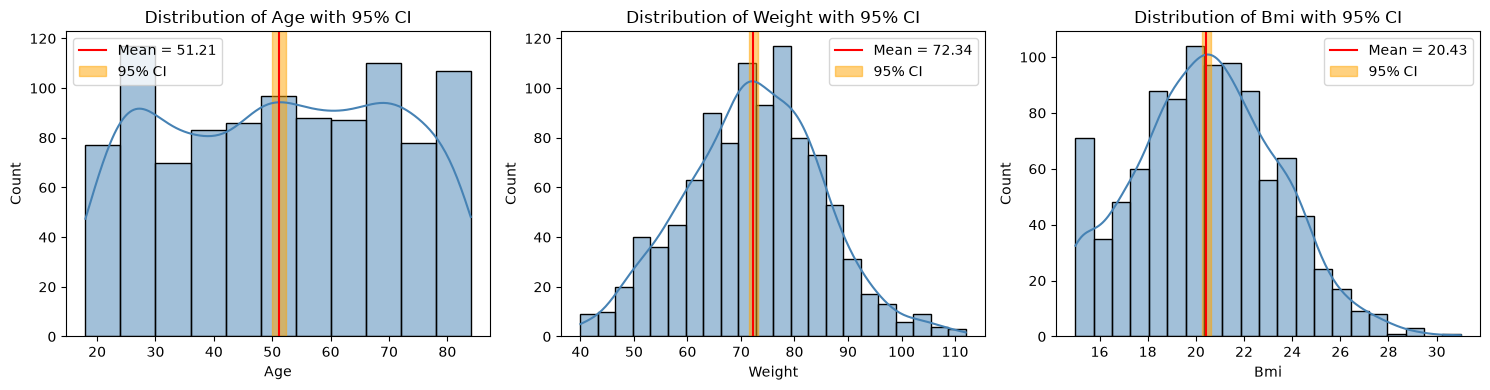

In [14]:
rows = []
for col in ["age", "weight", "bmi", "blood_pressure", "cholesterol_level", "glucose_level"]:
    x = df[col]
    lo, hi = stats.t.interval(0.95, len(x)-1, loc=x.mean(), scale=stats.sem(x))
    rows.append([col, x.mean(), x.std(ddof=1), lo, hi])
ci = pd.DataFrame(rows, columns=["variable", "mean", "std", "ci_lower", "ci_upper"]).round(2)
display(ci)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["age", "weight", "bmi"]):
    r = ci[ci.variable == col].iloc[0]
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.axvline(r["mean"], color="red", label=f"Mean = {r['mean']}")
    ax.axvspan(r["ci_lower"], r["ci_upper"], color="orange", alpha=0.5, label="95% CI")
    ax.set_title(f"Distribution of {col.title()} with 95% CI")
    ax.set_xlabel(col.title()); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout(); plt.show()

### Step 5: Chi-Square Test (Smoking vs Diabetes)

diabetes        False  True 
smoking_status              
Former Smoker     148     45
Non-Smoker        436    113
Smoker            190     68

Chi-square = 3.415 | Critical value = 5.991 | p-value = 0.1813
Decision = Fail to reject H0


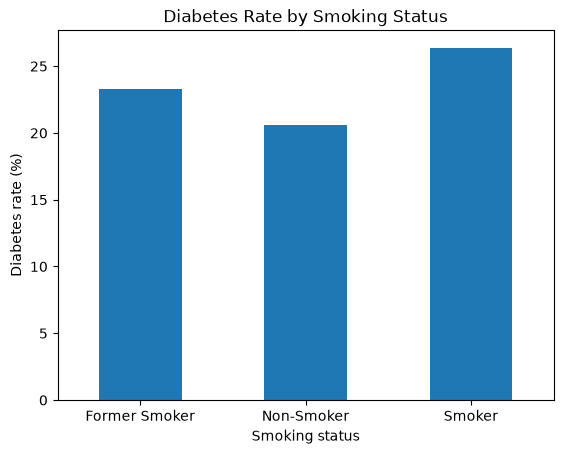

In [15]:
table = pd.crosstab(df.smoking_status, df.diabetes)
print(table)

chi2, p, dof, expected = stats.chi2_contingency(table)
critical = stats.chi2.ppf(0.95, dof)

print("\nChi-square =", round(chi2, 3), "| Critical value =", round(critical, 3), "| p-value =", round(p, 4))
print("Decision =", "Reject H0" if p < 0.05 else "Fail to reject H0")

(df.groupby("smoking_status").diabetes.mean() * 100).plot(kind="bar")
plt.title("Diabetes Rate by Smoking Status")
plt.xlabel("Smoking status"); plt.ylabel("Diabetes rate (%)"); plt.xticks(rotation=0)
plt.show()

### Step 6: ANOVA (Diabetes rate across Age Groups)

F = 25.114 | Critical value = 2.381 | p-value = 7.709525442171926e-20
Decision = Reject H0


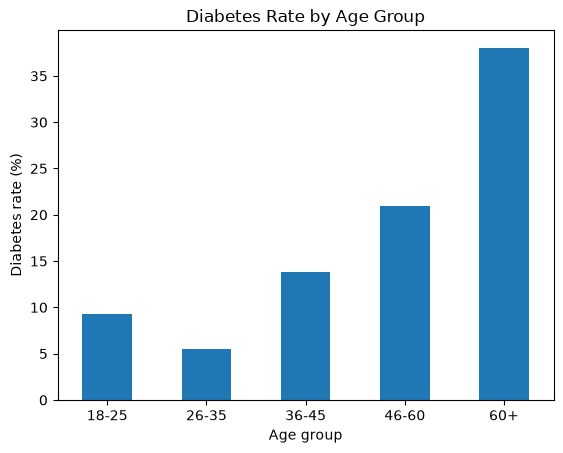

In [17]:
groups = [g["diabetes"].astype(int) for _, g in df.groupby("age_group")]

F, p = stats.f_oneway(*groups)
critical = stats.f.ppf(0.95, 4, len(df) - 5)

print("F =", round(F, 3), "| Critical value =", round(critical, 3), "| p-value =", p)
print("Decision =", "Reject H0" if p < 0.05 else "Fail to reject H0")

(df.groupby("age_group").diabetes.mean() * 100).plot(kind="bar")
plt.title("Diabetes Rate by Age Group")
plt.xlabel("Age group"); plt.ylabel("Diabetes rate (%)"); plt.xticks(rotation=0)
plt.show()

### Step 7: Covariance and Correlation (Age vs BMI)

Covariance (Age, BMI) = 21.225
Pearson r = 0.374 (p = 1.77e-34) | Spearman rho = 0.365 (p = 6.22e-33)


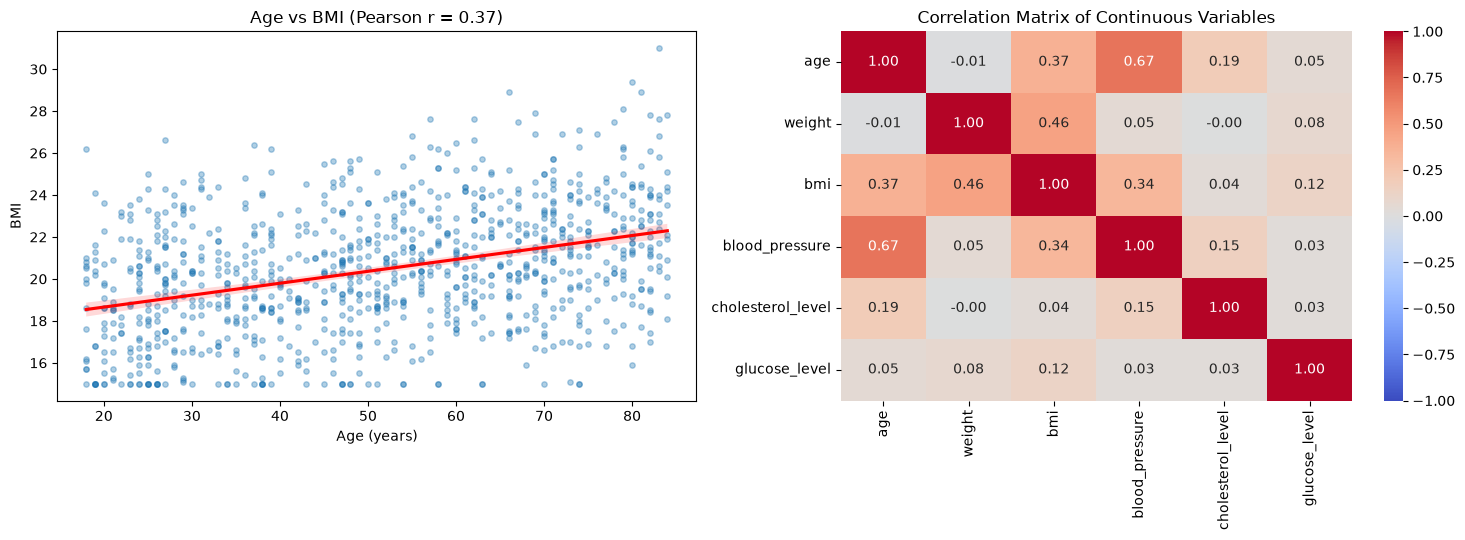

In [20]:
cov = np.cov(df.age, df.bmi, ddof=1)[0, 1]
r, p_r = stats.pearsonr(df.age, df.bmi)
rho, p_s = stats.spearmanr(df.age, df.bmi)
print(f"Covariance (Age, BMI) = {cov:.3f}")
print(f"Pearson r = {r:.3f} (p = {p_r:.2e}) | Spearman rho = {rho:.3f} (p = {p_s:.2e})")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.regplot(data=df, x="age", y="bmi", scatter_kws={"alpha": 0.35, "s": 15}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title(f"Age vs BMI (Pearson r = {r:.2f})"); axes[0].set_xlabel("Age (years)"); axes[0].set_ylabel("BMI")

cols = ["age", "weight", "bmi", "blood_pressure", "cholesterol_level", "glucose_level"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation Matrix of Continuous Variables")
plt.tight_layout(); plt.show()

### Step 8: Final Summary
| Test | Result | Decision |
|---|---|---|
| t-test / z-test (BMI vs Diabetes) | p < 0.05 | **Reject H₀** |
| Chi-square (Smoking vs Diabetes) | p = 0.18 | **Fail to reject H₀** |
| ANOVA (Age group vs Diabetes) | p < 0.05 | **Reject H₀** |
| Correlation (Age vs BMI) | p < 0.05 | **Reject H₀** |